In [1]:
%pylab inline
%load_ext autoreload
%autoreload 2

import os,sys
#thisScriptDir = os.path.dirname(os.path.realpath(__file__))
#sys.path.append(os.path.join(thisScriptDir, '../../'))
sys.path.append('/Users/tel/git/lm/utils/python/lm_anal')
cm.jet.set_bad(cm.jet(0))

numpy.set_printoptions(precision=3, threshold=1e6, linewidth=1e6)

Populating the interactive namespace from numpy and matplotlib


In [2]:
from ffluxHistsVsBFHistsExample import FFluxHistsVsBFHistsExample

In [60]:
defaultFilePath = '../../../../../regression/biphasic_switch.lm'

fflux_cppe3FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+03/genetic_toggle_switch.lm'
fflux_cppe4FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+04/genetic_toggle_switch.lm'
fflux_cppe5FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+05/genetic_toggle_switch.lm'
ffluxCppFileList = [fflux_cppe3FilePath, fflux_cppe4FilePath, fflux_cppe5FilePath]

fflux_wi04FilePath = '../../../../../regression/gts_writeInterval0.4.lm'
fflux_wi1FilePath = '../../../../../regression/gts_writeInterval1.0.lm'
fflux_wi4FilePath = '../../../../../regression/gts_writeInterval4.0.lm'
ffluxWiFileList = [fflux_wi04FilePath, fflux_wi1FilePath, fflux_wi4FilePath]

allFileList = [defaultFilePath] + ffluxCppFileList + ffluxWiFileList
allIntList = [filePath + 'int' for filePath in allFileList]

for fPath in allIntList:
    try:
        os.remove(fPath)
    except FileNotFoundError:
        pass

# example = FFluxHistsVsBFHistsExample()
# examplee3 = FFluxHistsVsBFHistsExample(ffluxFilePath=ffluxe3FilePath)
# examplee4 = FFluxHistsVsBFHistsExample(ffluxFilePath=ffluxe4FilePath)
# examplee5 = FFluxHistsVsBFHistsExample(ffluxFilePath=ffluxe5FilePath)
example_wi04 = FFluxHistsVsBFHistsExample(ffluxFilePath=fflux_wi04FilePath)
example = example_wi04

the FORWARD phase zero best fit weight is: 0.00000153
the BACKWARD phase zero best fit weight is: 0.00000153


In [61]:
example.bfHist.normalize()
histArr = (example.bfHist.h - example.ffluxHist.h)/example.bfHist.h
print(example.bfHist.getKLDivergence(example.ffluxHist))
print(np.sum(example.bfHist.h))
print(np.sum(example.ffluxHist.h))

0.014222105674
1.0
1.0


/usr/local/lib/python3.4/site-packages/IPython/kernel/__main__.py:2: RuntimeWarning: divide by zero encountered in true_divide
  from IPython.kernel.zmq import kernelapp as app
/usr/local/lib/python3.4/site-packages/IPython/kernel/__main__.py:2: RuntimeWarning: invalid value encountered in true_divide
  from IPython.kernel.zmq import kernelapp as app


(0, 60)

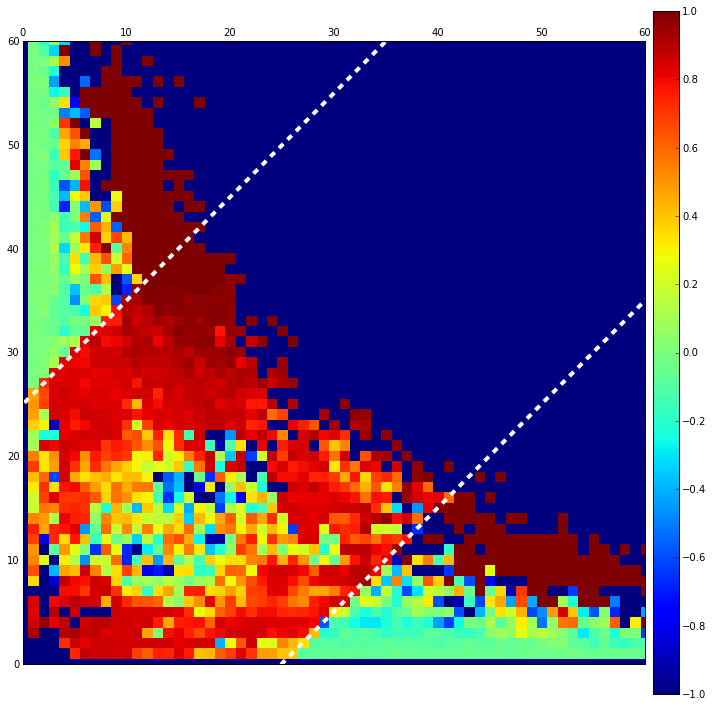

In [62]:
from matplotlib.colors import LogNorm
f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
axcolor = f.add_axes([0.90, 0.02, 0.03, 0.79])
t = np.logspace(-4,10,base=10,num=20)
im = ax.matshow(histArr, cmap=cm.jet, origin='lower',vmin=-1, vmax=1) #norm=LogNorm()
for b in (25,-25):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
f.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')
ax.set_xlim(0,60)
ax.set_ylim(0,60)

In [63]:
modFFluxArr = example.ffluxHist.phase_n_order_parameter_values['FORWARD'].combine( \
              example.ffluxHist.phase_n_order_parameter_values['BACKWARD'])
modBFArr = example.bfHist.getCopy()
zeroMask = np.logical_or(modFFluxArr.h==0, modBFArr.h==0)
modBFArr.remask(zeroMask)
modBFArr.normalize()
modFFluxArr.remask(zeroMask)
modFFluxArr.normalize()
print(modBFArr.getKLDivergence(modFFluxArr))
print(np.sum(modFFluxArr.h))
print(np.sum(modBFArr.h))
print(np.all(modFFluxArr.h.nonzero()[0]==modBFArr.h.nonzero()[0]))
print(np.all(modFFluxArr.h.nonzero()[1]==modBFArr.h.nonzero()[1]))
print(np.any((modFFluxArr.h==modBFArr.h)))
print(np.any(np.isnan((modBFArr.h - modFFluxArr.h)/modBFArr.h)))
modHistArr = (modBFArr.h - modFFluxArr.h)/modBFArr.h

0.0637731222354
1.0
1.0
True
True
True
True


/usr/local/lib/python3.4/site-packages/IPython/kernel/__main__.py:14: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/IPython/kernel/__main__.py:15: RuntimeWarning: invalid value encountered in true_divide


(0, 60)

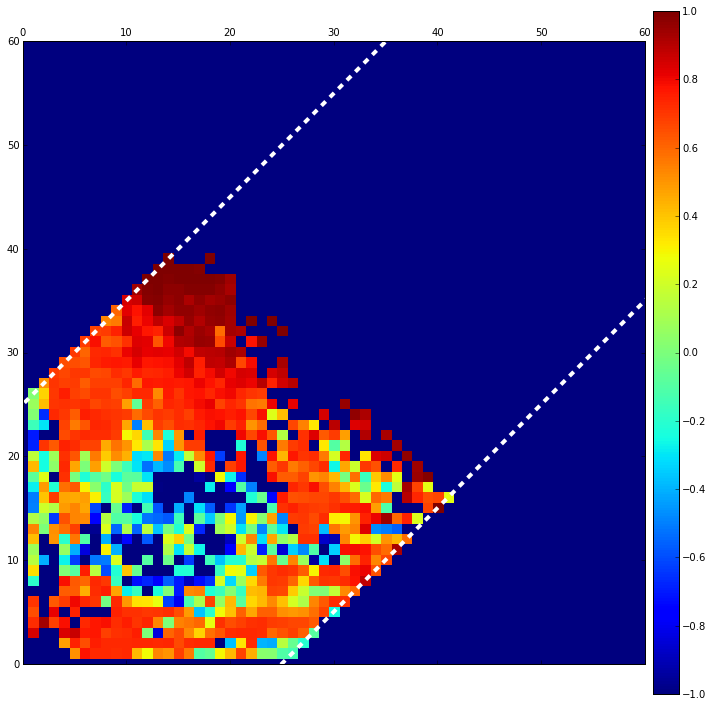

In [66]:
from matplotlib.colors import LogNorm
f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
axcolor = f.add_axes([0.90, 0.02, 0.03, 0.79])
t = np.logspace(-4,10,base=10,num=20)
im = ax.matshow(modHistArr, cmap=cm.jet, origin='lower',vmin=-1, vmax=1) #norm=LogNorm()
for b in (25,-25):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
f.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')
ax.set_xlim(0,60)
ax.set_ylim(0,60)

In [38]:
bfHistNorm = example.bfHist.getCopy()
bfHistNorm.normalize()
bf1d = np.array((np.arange(-100,101),[bfHistNorm.h.trace(offset=i) for i in np.arange(-100,101)]))
ffluxHistNorm = example.ffluxHist.getCopy()
ffluxHistNorm.normalize()
fflux1d_wi4 = np.array((np.arange(-100,101), [ffluxHistNorm.h.trace(offset=i) for i in np.arange(-100,101)]))
print(bf1d[0].shape)

(201,)


In [34]:
start,end=bf1d[0].searchsorted((-5,5))
print(start,end)
# bf1d[1,start:end]

95 105


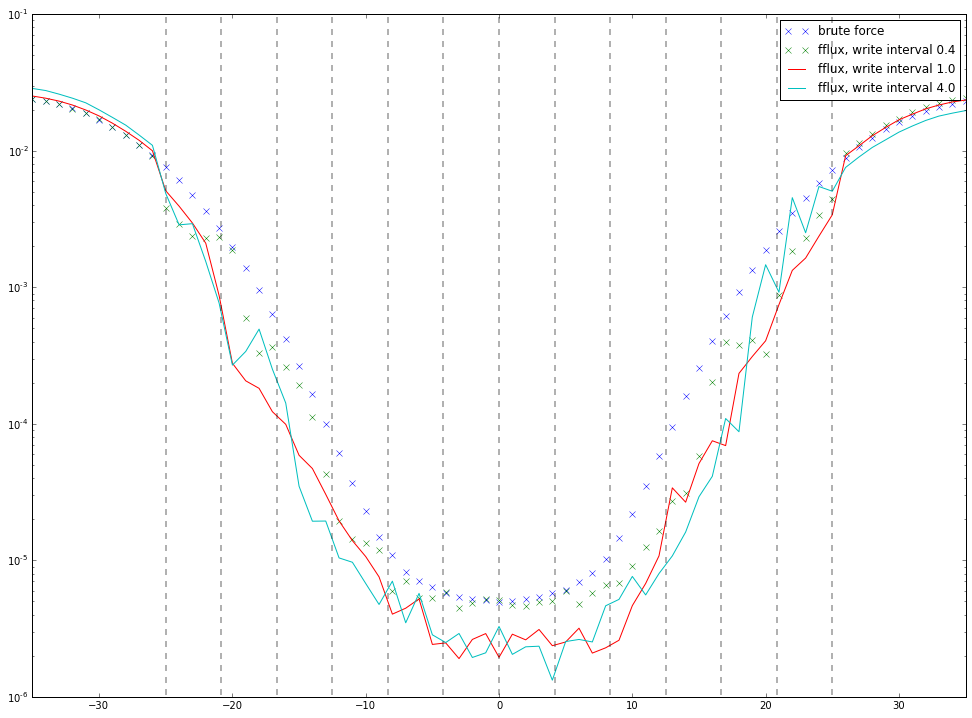

In [80]:
# normalized across everything

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1d[0], bf1d[1]/bf1d[1].sum(), 'x', label='brute force')
ax.plot(fflux1d_wi04[0], fflux1d_wi04[1]/fflux1d_wi04[1].sum(), 'x', label='fflux, write interval 0.4')
ax.plot(fflux1d_wi1[0], fflux1d_wi1[1]/fflux1d_wi1[1].sum(), label='fflux, write interval 1.0')
ax.plot(fflux1d_wi4[0], fflux1d_wi4[1]/fflux1d_wi4[1].sum(), label='fflux, write interval 4.0')
for b in np.linspace(-25,25,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
# for b in [-27,-25,-22,-18,-14,-12,-8,-5,-2,0,10,20]:
#     ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='best')
ax.set_xlim(-35,35)
ax.set_ylim(1e-6,1e-1)
ax.set_yscale('log')

(-25, 25)

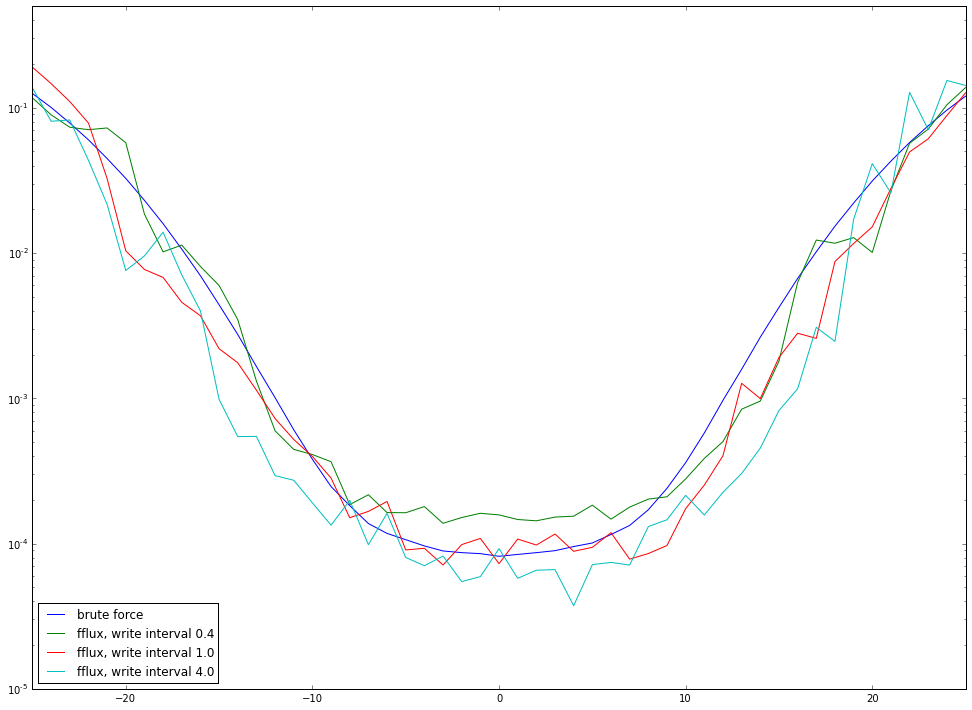

In [48]:
# normalized over xmin-xmax

xmin,xmax=-25,25
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1d_wi04Trans = fflux1d_wi04[:,s:e]
fflux1d_wi1Trans = fflux1d_wi1[:,s:e]
fflux1d_wi4Trans = fflux1d_wi4[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum(), label='brute force')
ax.plot(fflux1d_wi04Trans[0], fflux1d_wi04Trans[1]/fflux1d_wi04Trans[1].sum(), label='fflux, write interval 0.4')
ax.plot(fflux1d_wi1Trans[0], fflux1d_wi1Trans[1]/fflux1d_wi1Trans[1].sum(), label='fflux, write interval 1.0')
ax.plot(fflux1d_wi4Trans[0], fflux1d_wi4Trans[1]/fflux1d_wi4Trans[1].sum(), label='fflux, write interval 4.0')
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(1e-5,5e-1)
ax.set_xlim(xmin, xmax)

(-35, 35)

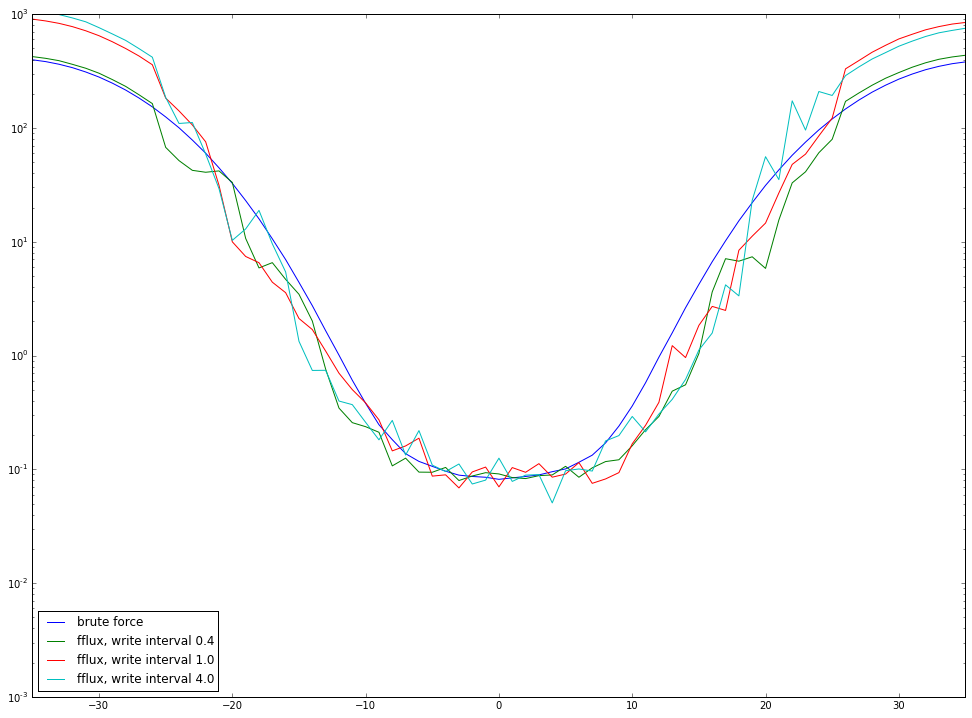

In [56]:
# normalized over -5,5

xmin,xmax=-35,35
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1d_wi04Trans = fflux1d_wi04[:,s:e]
fflux1d_wi1Trans = fflux1d_wi1[:,s:e]
fflux1d_wi4Trans = fflux1d_wi4[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1][-5-xmin:6-xmin].sum(), label='brute force')
ax.plot(fflux1d_wi04Trans[0], fflux1d_wi04Trans[1]/fflux1d_wi04Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 0.4')
ax.plot(fflux1d_wi1Trans[0], fflux1d_wi1Trans[1]/fflux1d_wi1Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 1.0')
ax.plot(fflux1d_wi4Trans[0], fflux1d_wi4Trans[1]/fflux1d_wi4Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 4.0')
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(1e-3,1e3)
ax.set_xlim(xmin, xmax)

(-25, 25)

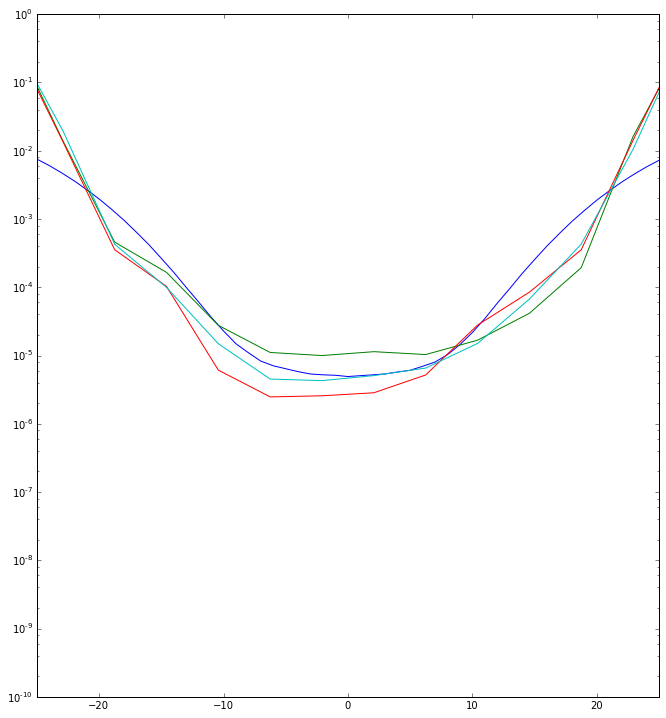

In [77]:
xmin,xmax=-100,100
s,e=bf1d[0].searchsorted((xmin,xmax))
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum())
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee3.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee4.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee5.ffluxHist.h)
# ax.plot(example.ffluxHist.h.trace())
ax.set_yscale('log')
ax.set_xlim(-25, 25)

In [67]:
examplee5.ffluxHist.h[1:-1]

array([  1.976e-02,   4.270e-04,   9.955e-05,   1.488e-05,   4.521e-06,   4.285e-06,   5.079e-06,   6.549e-06,   1.503e-05,   6.703e-05,   4.287e-04,   1.050e-02])